# Graficos de comparacao do Merge Sort

Este notebook junta os resultados de Python e C para gerar os dois graficos finais da analise:
- comparacao entre as linguagens no Caso Medio;
- comparacao entre os dados reais e a curva teorica `n log n`.

Os graficos usam escala logaritmica no eixo Y porque os tempos em Python e C possuem magnitudes diferentes.

## 1. Importacoes

In [9]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

## 2. Caminhos e configuracao visual

Aqui definimos os caminhos dos CSVs e um visual simples para manter a leitura organizada.

In [10]:
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

ROOT = Path('..').resolve()
RESULTS_DIR = ROOT / 'results'
GRAPHS_DIR = ROOT / 'graphs'
GRAPHS_DIR.mkdir(exist_ok=True)

CORES_LINGUAGEM = {
    'Python': '#2E86AB',
    'C': '#C73E1D',
}


## 3. Leitura dos dados

Nesta etapa lemos os dois arquivos CSV e juntamos tudo em uma unica tabela para facilitar a comparacao.

In [11]:
# Le os resultados das duas implementacoes.
df_python = pd.read_csv(RESULTS_DIR / 'python_results.csv')
df_c = pd.read_csv(RESULTS_DIR / 'c_results.csv')

# Junta os dois conjuntos em um unico DataFrame.
df_comparacao = pd.concat([df_python, df_c], ignore_index=True)

In [12]:
df_comparacao

,linguagem,cenario,tamanho,n,media_ms,desvio_ms,min_ms,max_ms,rodadas
0,Python,melhor_caso,pequeno,1000,2.2306,0.4495,1.6777,3.3689,30
1,Python,melhor_caso,medio,10000,22.0892,3.4251,19.6827,33.3268,30
2,Python,melhor_caso,grande,100000,267.1731,16.7301,242.6445,309.8046,30
3,Python,caso_medio,pequeno,1000,2.2060,0.5197,1.9564,4.0662,30
4,Python,caso_medio,medio,10000,25.7639,1.2348,24.1190,29.7981,30
5,Python,caso_medio,grande,100000,349.5182,30.4268,313.1663,409.8776,30
6,Python,pior_caso,pequeno,1000,1.9848,0.4835,1.7001,3.5191,30
7,Python,pior_caso,medio,10000,21.2625,1.3615,20.0802,25.8447,30
8,Python,pior_caso,grande,100000,255.7053,4.9912,247.7212,268.0577,30
9,C,melhor_caso,pequeno,1000,0.1542,0.0500,0.1175,0.3603,30


## 4. Comparacao entre Python e C no Caso Medio

Para comparar as duas linguagens de forma mais direta, usamos apenas o Caso Medio.

- Eixo X: mostra a quantidade de elementos da entrada, isto e, o valor de `n` usado em cada teste.
- Eixo Y: mostra o tempo medio de execucao em milissegundos.
- O recorte do Caso Medio foi escolhido porque ele representa melhor uma situacao geral de uso do algoritmo.
- Foi usada escala logaritmica no eixo Y para que os tempos medidos em Python e em C possam ser comparados sem esconder os menores valores.
- Quando o ponto de uma linguagem fica abaixo da outra, isso indica menor tempo medio de execucao para o mesmo `n`.
- Neste caso, o grafico ajuda a visualizar que a implementacao em C permanece abaixo da implementacao em Python em todos os tamanhos analisados.

In [13]:
# Filtra apenas o Caso Medio para a comparacao entre linguagens.
df_caso_medio = (
    df_comparacao[df_comparacao['cenario'] == 'caso_medio']
    .sort_values(['linguagem', 'n'])
    .reset_index(drop=True)
)

df_caso_medio

,linguagem,cenario,tamanho,n,media_ms,desvio_ms,min_ms,max_ms,rodadas
0,C,caso_medio,pequeno,1000,0.1763,0.0468,0.1659,0.4236,30
1,C,caso_medio,medio,10000,2.6364,0.6737,1.9049,4.5247,30
2,C,caso_medio,grande,100000,27.5330,11.4657,20.0015,62.0373,30
3,Python,caso_medio,pequeno,1000,2.2060,0.5197,1.9564,4.0662,30
4,Python,caso_medio,medio,10000,25.7639,1.2348,24.1190,29.7981,30
5,Python,caso_medio,grande,100000,349.5182,30.4268,313.1663,409.8776,30


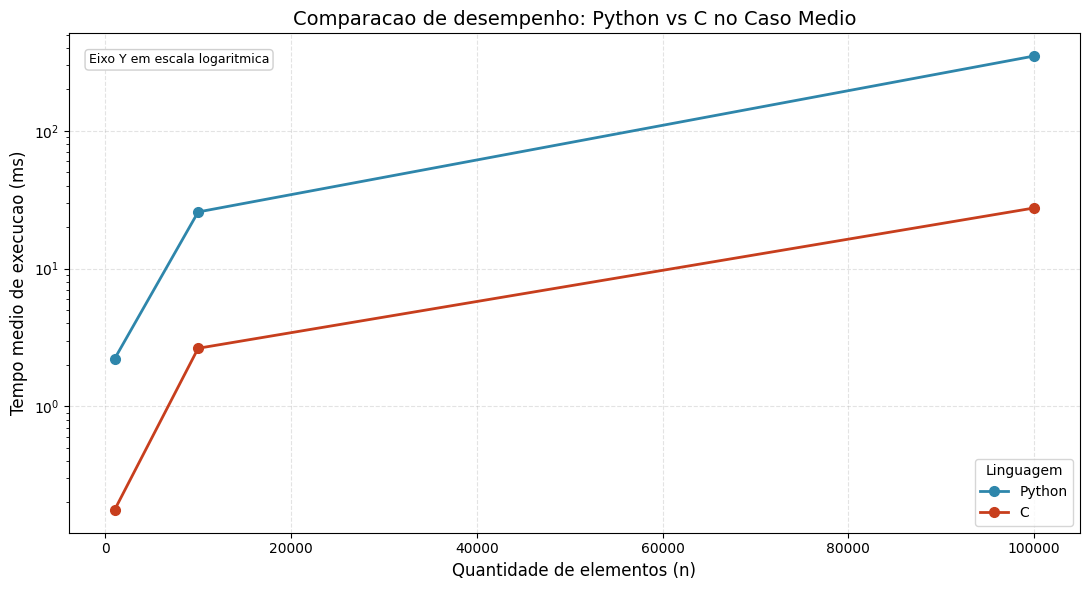

In [14]:
# Cria o grafico de linhas para comparar Python e C no Caso Medio.
fig, ax = plt.subplots()

for linguagem in ['Python', 'C']:
    grupo = df_caso_medio[df_caso_medio['linguagem'] == linguagem]
    ax.plot(
        grupo['n'],
        grupo['media_ms'],
        marker='o',
        linewidth=2.5,
        markersize=8,
        color=CORES_LINGUAGEM[linguagem],
        label=linguagem,
    )

# Ajusta os elementos principais do grafico.
ax.set_title('Comparacao do tempo medio de execucao entre Python e C no Caso Medio')
ax.set_xlabel('Quantidade de elementos (n)')
ax.set_ylabel('Tempo medio de execucao (ms)')
ax.set_xticks(df_caso_medio['n'].drop_duplicates().tolist())
ax.set_yscale('log')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(title='Linguagem')

# Explica de forma curta o motivo da escala logaritmica e o recorte usado.
ax.text(
    0.02,
    0.96,
    'Eixo Y em escala logaritmica',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#D0D0D0', 'boxstyle': 'round,pad=0.3'}
)
ax.text(
    0.98,
    0.14,
    'Recorte: apenas o Caso Medio',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#D0D0D0', 'boxstyle': 'round,pad=0.3'}
)
ax.text(
    0.98,
    0.06,
    'Tamanhos comparados: n = 1000, 10000 e 100000',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#D0D0D0', 'boxstyle': 'round,pad=0.3'}
)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'python_vs_c_caso_medio.png', dpi=200)
plt.show()
plt.close()

## 5. Dados reais versus curva teorica `n log n`

Neste grafico, comparamos os tempos medios medidos com uma curva teorica baseada em `n * log2(n)`.

- Eixo X: mostra a quantidade de elementos da entrada, isto e, o valor de `n`.
- Eixo Y: mostra o tempo medio de execucao em milissegundos.
- A curva teorica foi calculada com `n * log2(n)` e depois ajustada de escala para ficar comparavel visualmente com os dados reais.
- Esse ajuste de escala nao muda a classe assintotica da curva. Ele serve apenas para comparar o formato do crescimento, e nao para forcar igualdade numerica entre teoria e experimento.
- Foi usada escala logaritmica no eixo Y para facilitar a leitura conjunta dos valores menores e maiores.
- O ponto principal da leitura e comparar a tendencia de crescimento: se os dados reais acompanham a forma geral da linha teorica, isso reforca a compatibilidade com o comportamento esperado de `n log n`.

In [15]:
# Calcula a media geral dos tempos por n considerando os dois CSVs.
media_geral_por_n = (
    df_comparacao.groupby('n', as_index=False)['media_ms']
    .mean()
    .sort_values('n')
    .reset_index(drop=True)
)

# Calcula a curva teorica n log2(n).
media_geral_por_n['curva_n_log_n'] = media_geral_por_n['n'].apply(lambda n: n * math.log2(n))

# Escala a curva teorica para ficar comparavel com os dados reais.
fator_escala = media_geral_por_n['media_ms'].iloc[-1] / media_geral_por_n['curva_n_log_n'].iloc[-1]
media_geral_por_n['curva_teorica_escalada'] = media_geral_por_n['curva_n_log_n'] * fator_escala

# Separa os dados reais por linguagem para desenhar duas linhas medidas.
df_teorico = (
    df_comparacao.groupby(['linguagem', 'n'], as_index=False)['media_ms']
    .mean()
    .sort_values(['linguagem', 'n'])
)

media_geral_por_n

,n,media_ms,curva_n_log_n,curva_teorica_escalada
0,1000,1.145583,9.965784e+03,0.936659
1,10000,12.532633,1.328771e+05,12.488780
2,100000,156.109750,1.660964e+06,156.109750


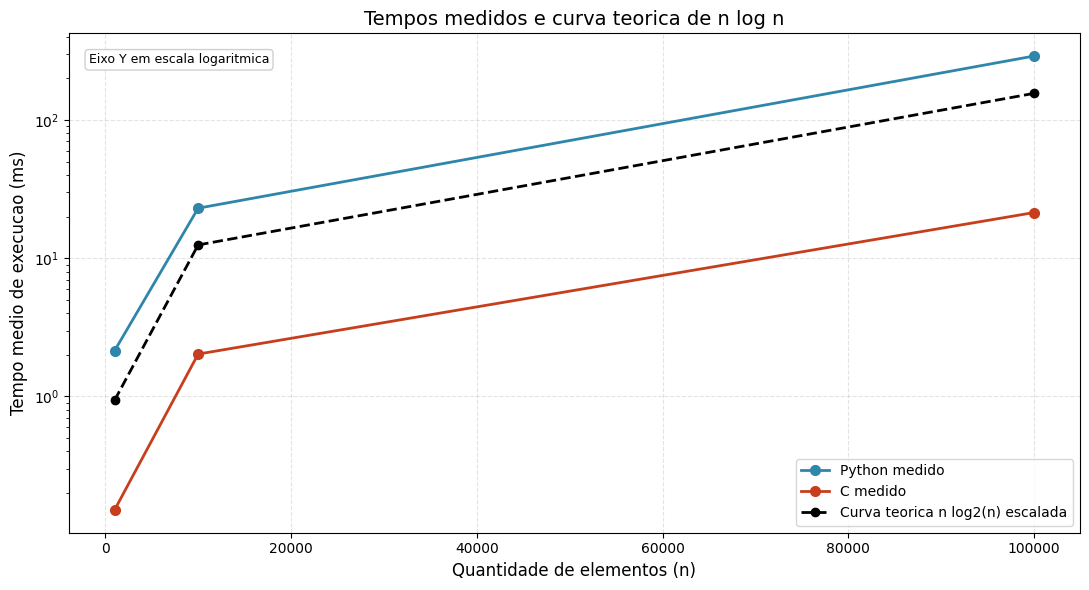

In [16]:
# Desenha os tempos medios por linguagem e a curva teorica escalada.
fig, ax = plt.subplots()

for linguagem in ['Python', 'C']:
    grupo = df_teorico[df_teorico['linguagem'] == linguagem]
    ax.plot(
        grupo['n'],
        grupo['media_ms'],
        marker='o',
        linewidth=2.5,
        markersize=8,
        color=CORES_LINGUAGEM[linguagem],
        label=f'{linguagem} medido',
    )

ax.plot(
    media_geral_por_n['n'],
    media_geral_por_n['curva_teorica_escalada'],
    marker='o',
    linestyle='--',
    color='black',
    linewidth=2.2,
    label='Curva teorica proporcional a n log2(n)',
)

# Ajusta titulo, eixos, legenda e grade.
ax.set_title('Comparacao entre tempos medidos e a tendencia teorica de n log n')
ax.set_xlabel('Quantidade de elementos (n)')
ax.set_ylabel('Tempo medio de execucao (ms)')
ax.set_xticks(media_geral_por_n['n'].tolist())
ax.set_yscale('log')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend()

# Destaca que a linha teorica foi apenas escalada para comparacao visual.
ax.text(
    0.02,
    0.96,
    'Eixo Y em escala logaritmica',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#D0D0D0', 'boxstyle': 'round,pad=0.3'}
)
ax.text(
    0.98,
    0.08,
    'Linha teorica escalada apenas para comparar a tendencia',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#D0D0D0', 'boxstyle': 'round,pad=0.3'}
)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'real_vs_teorico_nlogn.png', dpi=200)
plt.show()
plt.close()